In [1]:
import torch
from torchvision import datasets
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import RandomForestClassifier

import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from abc import ABC, abstractmethod

In [2]:
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True
)

# EDA

In [3]:
train_images = train_dataset.data.numpy()
train_labels = train_dataset.targets.numpy()
test_images = test_dataset.data.numpy()
test_labels = test_dataset.targets.numpy()

In [4]:
train_shape = train_images.shape
test_shape = test_images.shape

print("Train:\t\t", train_shape)
print("Test:\t\t", test_shape)
print("Classes:\t", np.unique(train_labels))
print("Min value:\t", np.min(train_images))
print("Max value:\t", np.max(train_images))

Train:		 (60000, 28, 28)
Test:		 (10000, 28, 28)
Classes:	 [0 1 2 3 4 5 6 7 8 9]
Min value:	 0
Max value:	 255


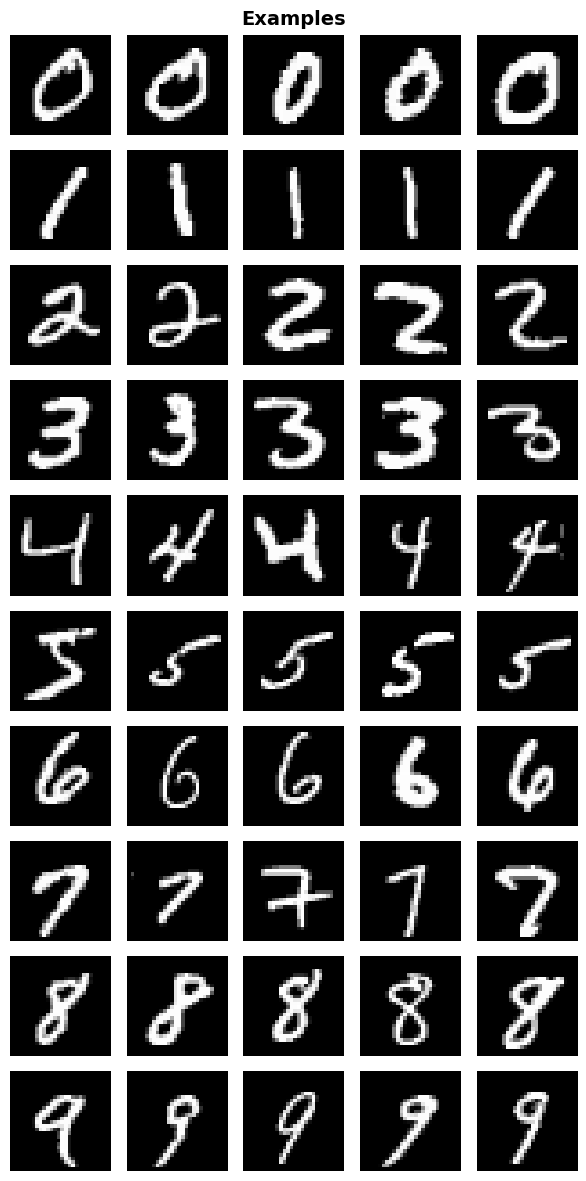

In [5]:
fig, axes = plt.subplots(10, 5, figsize=(6, 12))
fig.suptitle("Examples", fontsize=14, fontweight='bold')

for digit in range(10):
    idxs = np.where(train_labels == digit)[0][:5]
    for col, idx in enumerate(idxs):
        ax = axes[digit][col]
        ax.imshow(train_images[idx], cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(str(digit), fontsize=12, rotation=0, labelpad=15)

plt.tight_layout()
plt.show()

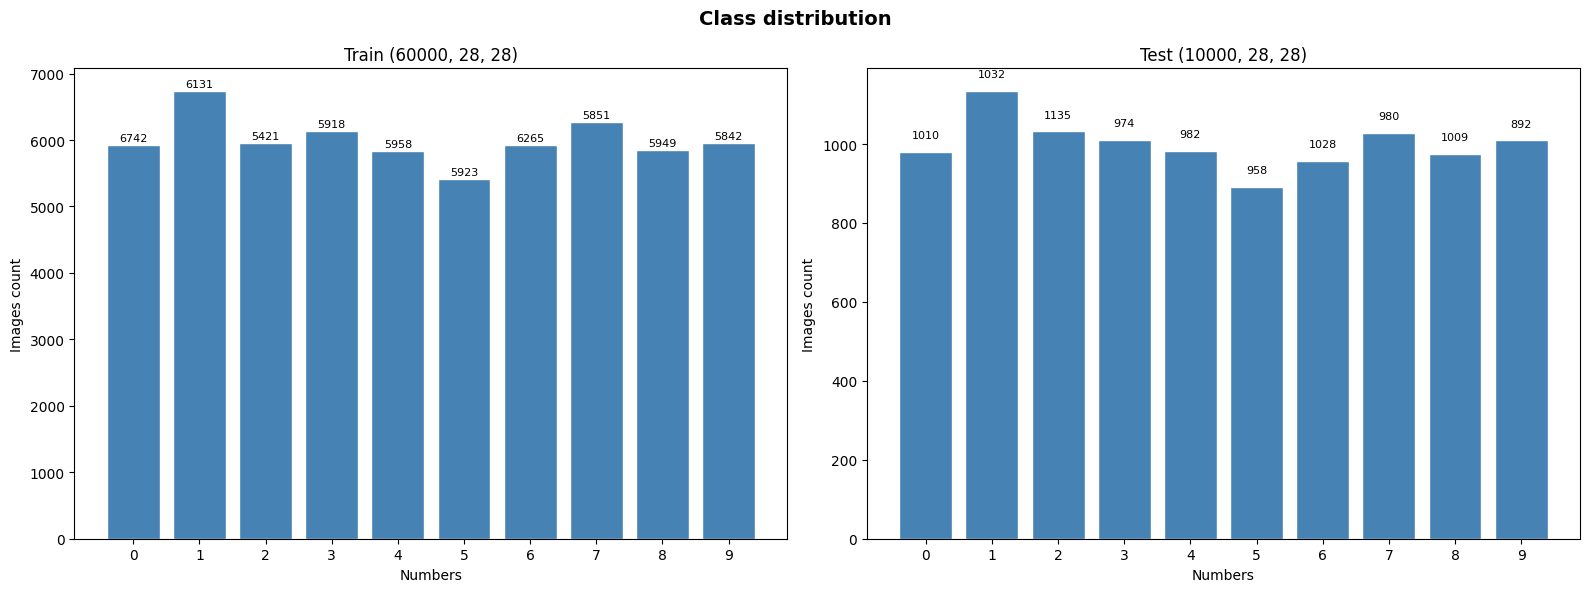

Class 0: 5923 (9.9%)
Class 1: 6742 (11.2%)
Class 2: 5958 (9.9%)
Class 3: 6131 (10.2%)
Class 4: 5842 (9.7%)
Class 5: 5421 (9.0%)
Class 6: 5918 (9.9%)
Class 7: 6265 (10.4%)
Class 8: 5851 (9.8%)
Class 9: 5949 (9.9%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Class distribution", fontsize=14, fontweight='bold')

for ax, labels, title in zip(axes,
                              [train_labels, test_labels],
                              [f"Train {train_shape}", f"Test {test_shape}"]):
    counts = Counter(labels)
    bars = ax.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel("Numbers")
    ax.set_ylabel("Images count")
    ax.set_xticks(range(10))
    for bar, (digit, cnt) in zip(bars, sorted(counts.items())):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(cnt), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
for digit in range(10):
    cnt = (train_labels == digit).sum()
    print(f"Class {digit}: {cnt} ({cnt/len(train_labels)*100:.1f}%)")

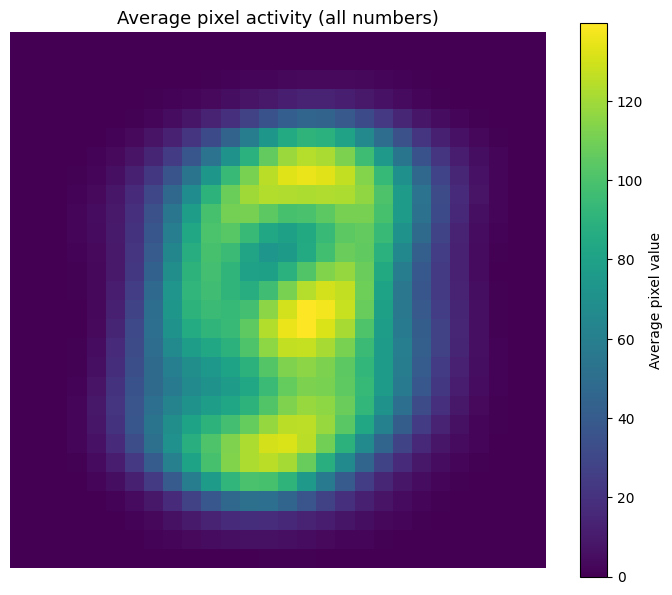

In [7]:
mean_all = train_images.mean(axis=0)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mean_all, cmap='viridis')
ax.set_title("Average pixel activity (all numbers)", fontsize=13)
ax.axis('off')
plt.colorbar(im, ax=ax, label="Average pixel value")
plt.tight_layout()
plt.show()

# Classifiers

## Classifier Interface

In [8]:
class MnistClassifierInterface(ABC):
    @abstractmethod
    def train(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Train the model.

        Args:
            X: Images array.
            y: Labels array.
        """

    @abstractmethod
    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict class labels.

        Args:
            X: Images array.

        Returns:
            Labels array.
        """

## Random Forest

In [9]:
class _RandomForestClassifier(MnistClassifierInterface):
    def __init__(self, n_estimators: int = 200, random_state: int = 42):
        self._model = RandomForestClassifier(
            n_estimators=n_estimators,
            n_jobs=-1,
            random_state=random_state,
        )

    def train(self, X: np.ndarray, y: np.ndarray) -> None:
        X = X.reshape(len(X), -1)
        self._model.fit(X / 255.0, y)

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = X.reshape(len(X), -1)
        return self._model.predict(X / 255.0)

## Feed-Forward Neural Network

In [10]:
class _FeedForwardClassifier(MnistClassifierInterface):

    class _Net(nn.Module):
        def __init__(self):
            super().__init__()
            self.sequence = nn.Sequential(
                nn.Flatten(),
                nn.Linear(784, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(512, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, 10)
            )
        
        def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.sequence(x)

    def __init__(self, epochs: int = 15, batch_size: int = 256, lr: float =1e-3):
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self._Net().to(self.device)

    def _to_loader(self, X: np.ndarray, y: np.ndarray | None, shuffle: bool) -> DataLoader:
        X_t = torch.tensor(X / 255.0, dtype=torch.float32)
        if y is not None:
            y_t = torch.tensor(y, dtype=torch.long)
            return DataLoader(
                TensorDataset(X_t, y_t),
                batch_size=self.batch_size, shuffle=shuffle
                )
        
        return DataLoader(
            TensorDataset(X_t),
            batch_size=self.batch_size, shuffle=False
            )

    def train(self, X: np.ndarray, y: np.ndarray) -> None:
        loader = self._to_loader(X, y, shuffle=True)
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

        self.model.train()
        for epoch in range(self.epochs):
            total_loss = 0.0

            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)

                optimizer.zero_grad()
                loss = criterion(self.model(xb), yb)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            
            scheduler.step()
            print(f"[FFNN] Epoch {epoch + 1}/{self.epochs}"
                  f"\tloss={total_loss / len(loader):.4f}")
            
    @torch.no_grad()
    def predict(self, X: np.ndarray):
        loader = self._to_loader(X, None, shuffle=False)
        results = []

        self.model.eval()
        for (xb,) in loader:
            xb = xb.to(self.device)
            logits = self.model(xb)
            results.append(torch.softmax(logits, dim=1).cpu())
        
        result_tensor = torch.cat(results).numpy().astype(np.float32)

        return result_tensor.argmax(axis=1).astype(int)

## Convolutional Neural Network

In [11]:
class _CNNClassifier(MnistClassifierInterface):
 
    class _Net(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                # block 1
                nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 28x28
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.Conv2d(32, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.MaxPool2d(2),                              # 14x14
                nn.Dropout2d(0.25),
                # block 2
                nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 14x14
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.Conv2d(64, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.MaxPool2d(2),                               # 7x7
                nn.Dropout2d(0.25),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(64 * 7 * 7, 256),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(256, 10),
            )
 
        def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.classifier(self.features(x))  
        
    def __init__(self, epochs: int = 15, batch_size: int = 256, lr: float =1e-3):
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self._Net().to(self.device)

    def _to_loader(self, X: np.ndarray, y: np.ndarray | None, shuffle: bool) -> DataLoader:
        X_t = torch.tensor(X / 255.0, dtype=torch.float32)
        if y is not None:
            y_t = torch.tensor(y, dtype=torch.long)
            return DataLoader(
                TensorDataset(X_t, y_t),
                batch_size=self.batch_size, shuffle=shuffle
                )
        
        return DataLoader(
            TensorDataset(X_t),
            batch_size=self.batch_size, shuffle=False
            )
    
    def train(self, X: np.ndarray, y: np.ndarray) -> None:
        loader = self._to_loader(X, y, shuffle=True)
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

        self.model.train()
        for epoch in range(self.epochs):
            total_loss = 0.0

            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)

                optimizer.zero_grad()
                loss = criterion(self.model(xb), yb)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            
            scheduler.step()
            print(f"[CNN] Epoch {epoch + 1}/{self.epochs}"
                  f"\tloss={total_loss / len(loader):.4f}")
    
    @torch.no_grad()
    def predict(self, X: np.ndarray):
        loader = self._to_loader(X, None, shuffle=False)
        results = []

        self.model.eval()
        for (xb,) in loader:
            xb = xb.to(self.device)
            logits = self.model(xb)
            results.append(torch.softmax(logits, dim=1).cpu())
        
        result_tensor = torch.cat(results).numpy().astype(np.float32)

        return result_tensor.argmax(axis=1).astype(int)

In [15]:
from typing import Literal


_REGISTRY: dict[str, type] = {
    "rf": _RandomForestClassifier,
    "nn":  _FeedForwardClassifier,
    "cnn":           _CNNClassifier,
}

Algorithm = Literal["cnn", "rf", "nn"]

In [18]:
_REGISTRY["rf"]

__main__._RandomForestClassifier

In [ ]:
class MnistClassifier:
    """
    Unified facade for three MNIST classifiers.
 
    Parameters
    ----------
    algorithm : "random_forest" | "feed_forward" | "cnn"
    **kwargs  : forwarded to the underlying classifier constructor
 
    Examples
    --------
    >>> clf = MnistClassifier(algorithm="cnn")
    >>> clf.train(X_train, y_train)
    >>> labels = clf.predict(X_test)          # np.ndarray  shape (N,)
    >>> probs  = clf.predict_proba(X_test)    # np.ndarray  shape (N, 10)
    """

    def __init__(self, algorithm: Algorithm, **kwargs):
        if algorithm not in _REGISTRY:
            raise ValueError(
                f"Unknown algorithm '{algorithm}'. "
                f"Choose from: {list(_REGISTRY)}"
            )
        
        self.algorithm = algorithm
        self._clf: MnistClassifierInterface = _REGISTRY[algorithm](**kwargs)

    def train(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Parameters
        ----------
        X : np.ndarray  shape (N, 28)   pixel values in [0, 255]
        y : np.ndarray  shape (N,)       integer labels  0–9
        """
        print(f"[MnistClassifier] Training '{self.algorithm}' ...")
        self._clf.train(X, y)
        print(f"[MnistClassifier] Done.\n")